This file explores several models of nest acquisitions and parental care. We start with two models of these two features separated. We then model these two behaviors in a single model. In any model, the behavior is evolving in male and female individuals. The costs varies depending on the model used.

Libraries

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd

Model of nest acquisition. Here, each individual can lay eggs/sperm in a number of nest. The number of nest depends on the effort paid by the individual with a cost of gametes.

In [482]:
def f(x,y,a):
    return x*y*(np.exp(a*x) - np.exp(a*y))/(x*np.exp(a*x) - y*np.exp(a*y))

def nest(c):
    return 1+c*(mn-1) # m = maximum number of nest

def gametes(c,cmut):
    return (1-cmut)/nest(cmut)+(1-c)*(nest(c)-1)/nest(c)

def w_nest(x,y,a,cx,cy,cmut):
    return (1-cmut)/gametes(cx,cmut)*f(x*gametes(cx,cmut),y*(1-cy)/nest(cy),a)

male:  0.3021999650820449  female:  0


C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\1353304645.py:11: RuntimeWarning: invalid value encountered in divide
  return (1-cmut)/gametes(cx,cmut)*f(x*gametes(cx,cmut),y*(1-cy)/nest(cy),a)
C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\1353304645.py:2: RuntimeWarning: invalid value encountered in divide
  return x*y*(np.exp(a*x) - np.exp(a*y))/(x*np.exp(a*x) - y*np.exp(a*y))


Text(0, 0.5, 'female')

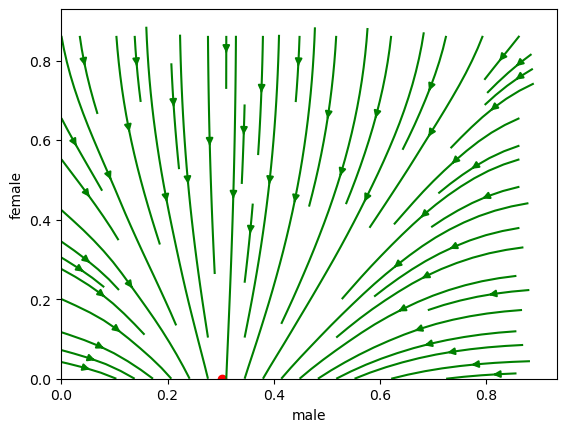

In [146]:
m = 5
x = 1e3
y = 1e1
a = 1e-2
h=1e-2

#Value at equilibrium and verification, we assume we start at (0,0)
cx = rd.uniform(0,1)
cy = rd.uniform(0,1)
for t in range(1,1000):
    cx += 0.001*np.sign((w_nest(x,y,a,cx,cy,cx+h)-w_nest(x,y,a,cx,cy,cx))/h)
    cy += 0.001*np.sign((w_nest(y,x,a,cy,cx,cy+h)-w_nest(y,x,a,cy,cx,cy))/h)
    if cy <0:
        cy = 0
cx_eq = cx
cy_eq = cy
print('male: ',cx, ' female: ',cy)

cx, cy = np.meshgrid(np.linspace(0,1,10),np.linspace(0,1,10))
u = (w_nest(x,y,a,cx,cy,cx+h)-w_nest(x,y,a,cx,cy,cx))/h
v = (w_nest(y,x,a,cy,cx,cy+h)-w_nest(y,x,a,cy,cx,cy))/h
plt.streamplot(cx, cy, u, v, color='g')

plt.scatter(cx_eq,cy_eq,color='red')
plt.xlabel('male')
plt.ylabel('female')

Male will look for more nests, female will keep only one nest.

Model of parental care. We assume males and female lay gametes in a given number of nest (mx and my) which can be changed if needed.

In [159]:
def w_pc(x,y,a,cx,cy,cmut,mx,my):
    gametes = (1-cmut)/mx+(mx-1)*(1-cx)/mx
    return (1-cmut)/gametes*f(x*gametes,y*(1-cy)/my,a)*(1+cmut)

C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\2899440883.py:14: RuntimeWarning: invalid value encountered in divide
  return m*(1-cmut)/((1-cmut)/m+(m-1)*(1-cx)/m)*f(x*(1-cmut+(m-1)*(1-cx))/mx,y*(1-cy)/my,a)*(1+cmut)
C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\1353304645.py:2: RuntimeWarning: invalid value encountered in divide
  return x*y*(np.exp(a*x) - np.exp(a*y))/(x*np.exp(a*x) - y*np.exp(a*y))


male:  0.11021669349584529  female:  0.00035468311389087043


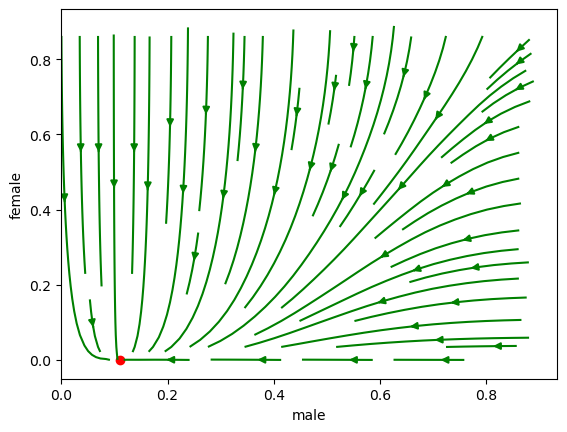

In [147]:
N = 10
cx, cy = np.meshgrid(np.linspace(0,1,N),np.linspace(0,1,N))

mx = 5
my = 5
x = 1e3
y = 1e1
a = 1e-2
h=1e-3

u = (wpc(x,y,a,cx,cy,cx+h,mx,my)-wpc(x,y,a,cx,cy,cx,mx,my))/h
v = (wpc(y,x,a,cy,cx,cy+h,mx,my)-wpc(y,x,a,cy,cx,cy,mx,my))/h
plt.streamplot(cx, cy, u, v, color='g')
plt.xlabel('male')
plt.ylabel('female')

#Value at equilibrium and verification
cx = rd.uniform(0,1)
cy = rd.uniform(0,1)
for t in range(1,1000):
    cx += 0.001*np.sign((wpc(x,y,a,cx,cy,cx+h,mx,my)-wpc(x,y,a,cx,cy,cx,mx,my))/h)
    cy += 0.001*np.sign((wpc(y,x,a,cy,cx,cy+h,my,mx)-wpc(y,x,a,cy,cx,cy,my,mx))/h)
print('male: ',cx, ' female: ',cy)
plt.scatter(cx,cy,color='red')

We see that male will give parental care but not female.

Model of coevolution of parental care and nest acquisition, we first assume the cost of both behavior diminished the production of gametes.
Changes: singular resources pool for the gametes production: x(1-cpcmut-cmmut) and a way to keep this cost between 0 and 1. Parental care is divided by the number of nest of each parent.

In [494]:
def W(x,y,a,cpcx,cpcy,cpcmut,cmx,cmy,cmmut):  
    gametes = (1-cpcmut-cmmut)/nest(cmmut)+(nest(cmx)-1)*(1-cpcx-cmx)/nest(cmx)
    care = (s0+cpcmut/(nest(cmmut)**g)+cpcx*(nest(cmx)-1)/(nest(cmx)**g)+cpcy/(nest(cmy)**(g-1)))
    return (1-cpcmut-cmmut)/gametes*f(x*gametes,y*(1-cpcy-cmy),a)*care #/nest(cmmut)


#Computation of the evolutionary equilibrium
def eqW(x,y,a,mn,s0,g):
    cpcx = rd.uniform(0,1)
    cpcy = rd.uniform(0,1)
    cmx = rd.uniform(0,1)
    cmy = rd.uniform(0,1)
    for t in range(1,T):
        if cpcx + cmx + h < 1:
            cpcx += (W(x,y,a,cpcx,cpcy,cpcx+h,cmx,cmy,cmx)-W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
        else:
            cmx = 1-cpcx-h
            cpcx += (W(x,y,a,cpcx,cpcy,cpcx+h,cmx,cmy,cmx)-W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
            
        if cpcy + cmy + h < 1:
           cpcy += (W(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
        else:
            cmy = 1-cpcy-h
            cpcy += (W(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
            
        if cpcx + cmx + h < 1:
            cmx += (W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx+h)-W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
        else:
            cpcx = 1-cmx-h
            cmx += (W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx+h)-W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
            
        if cpcy + cmy + h < 1:
            cmy += (W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy+h)-W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
        else: 
            cpcy = 1-cmy-h
            cmy += (W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy+h)-W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
    
    
        if cpcx <0:
            cpcx = 0
        if cpcy <0:
            cpcy = 0
        if cmx <0:
            cmx = 0
        if cmy <0:
            cmy = 0
        if cpcx >1:
            cpcx = 1
        if cpcy >1:
            cpcy = 1
        if cmx >1:
            cmx = 1
        if cmy >1:
            cmy = 1
    return cmx,cmy,cpcx,cpcy

In [548]:
x = 1e4
y = 1e2
a = 1e-2
s0 = 0.5
mn = 2
h = 1e-3
g = 1 # guarding nest or not: guarding -> 0, not guarding -> 1 or 2
N = 20
step = 1e-2
T = 20000
max_nest = 10
cmxv = np.zeros((max_nest-1,N))
cmyv = np.zeros((max_nest-1,N))
cpcxv = np.zeros((max_nest-1,N))
cpcyv = np.zeros((max_nest-1,N))
mnv = np.linspace(2,max_nest,max_nest-1)
s0v = np.linspace(0.25,2,N)
for i in range(0,max_nest-1):
    for j in range(0,N):
        mn = mnv[i]
        s0 = s0v[j]
        cmxv[i,j],cmyv[i,j],cpcxv[i,j],cpcyv[i,j] = eqW(x,y,a,mn,s0,g)
        

Plots of the results: on top: nest acquistion effort, on bottom: parental care. Left: male, right: female. Scale: dark blue: low, yellow: high.

Text(0.5, 0, 'basic fitness s0')

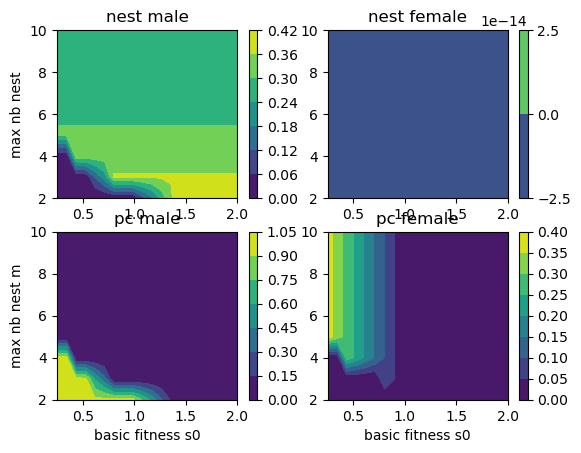

In [549]:
plt.subplot(2,2,1)
plt.contourf(s0v,mnv,cmxv)
plt.title('nest male')
plt.ylabel('max nb nest')

plt.colorbar()
plt.subplot(2,2,2)
plt.contourf(s0v,mnv,cmyv)
plt.title('nest female')
plt.colorbar()

plt.subplot(2,2,3)
plt.contourf(s0v,mnv,cpcxv)
plt.title('pc male')
plt.ylabel('max nb nest m')
plt.colorbar()
plt.xlabel('basic fitness s0')
plt.subplot(2,2,4)
plt.contourf(s0v,mnv,cpcyv)
plt.title('pc female')
plt.colorbar()
plt.xlabel('basic fitness s0')


In the next model, we assume the cost of parental care is paid by having less nest

In [461]:
def W1(x,y,a,cpcx,cpcy,cpcmut,cmx,cmy,cmmut):
    gametes = (1-cmmut)/nest(cmmut)+(mates(cmx)-1)*(1-cmx)/nest(cmx)
    return (1-cmmut)/gametes*f(x*gametes,y*(1-cpcmut)*(1-cmy)/nest(cmy),a)*(1+cpcmut/nest(cmmut)+cpcy/nest(cmy)) #/nest(cmmut)

In [462]:
x = 1e4
y = 1e2
a = 1e-2

# Initialization
cpcx = rd.uniform(0,1)
cpcy = rd.uniform(0,1)
cmx = rd.uniform(0,1)
cmy = rd.uniform(0,1)


h = 1e-3
step = 1e-3
T = 20000
R = 10
vr = np.zeros((2,R))
for r in range(1,R):
    for t in range(1,T):
        cpcx += (W1(x,y,a,cpcx,cpcy,cpcx+h,cmx,cmy,cmx)-W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
        cpcy += (W1(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
        cmy += (W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy+h)-W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
        cmx += (W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx+h)-W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)


        if cpcx <0:
            cpcx = 0
        if cpcy <0:
            cpcy = 0
        if cmx <0:
            cmx = 0
        if cmy <0:
            cmy = 0
        if cpcx >1:
            cpcx = 1
        if cpcy >1:
            cpcy = 1
        if cmx >1:
            cmx = 1
        if cmy >1:
            cmy = 1
    vr[:,r] = cmx,cpcy
#Printing results
print('male: nest: ',cmx, ' male: parental care: ',cpcx)
print('female: nest: ',cmy, ' female: parental care: ',cpcy)


male: nest:  0.30858030315850526  male: parental care:  0
female: nest:  0  female: parental care:  0.8449540167143007


Preliminary results: male: looking for more nests, give parental care. Female: not looking for more nests and not giving parental care
Expected given the assumptions: cost on the gametes. 

Secondary results: male: looking for more nests, no parental care. Female: not looking for more nests, gives parental care.  Here, we have parental care cost on the number of partners/nest.

In [469]:
def nest2(cnest,cpc):
    return (m+1)/2+(cnest-cpc)/2*(m-1)
    
def W2(x,y,a,cpcx,cpcy,cpcmut,cmx,cmy,cmmut):
    gametes = (1-cmmut)/nest2(cmmut,cpcmut)+(mates(cmx)-1)*(1-cmx)/nest2(cmx,cpcx)
    return (1-cmmut)/gametes*f(x*gametes,y*(1-cmy)/nest2(cmy,cpcy),a)*(1+cpcy/nest2(cmy,cpcy)+cpcmut/nest2(cmmut,cpcmut))

In [476]:
x = 1e4
y = 1e2
a = 1e-2

# Initialization
cpcx = rd.uniform(0,1)
cpcy = rd.uniform(0,1)
cmx = rd.uniform(0,1)
cmy = rd.uniform(0,1)


h = 1e-3
step = 1e-3
T = 20000
R = 10

for t in range(1,T):
    cpcx += (W2(x,y,a,cpcx,cpcy,cpcx+h,cmx,cmy,cmx)-W2(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W2(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
    cpcy += (W2(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W2(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W2(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
    cmy += (W2(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy+h)-W2(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W2(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
    cmx += (W2(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx+h)-W2(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W2(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)


    if cpcx <0:
        cpcx = 0
    if cpcy <0:
        cpcy = 0
    if cmx <0:
        cmx = 0
    if cmy <0:
        cmy = 0
    if cpcx >1:
        cpcx = 1
    if cpcy >1:
        cpcy = 1
    if cmx >1:
        cmx = 1
    if cmy >1:
        cmy = 1
#Printing results
print('male: nest: ',cmx, ' male: parental care: ',cpcx)
print('female: nest: ',cmy, ' female: parental care: ',cpcy)


male: nest:  0.1325823230998947  male: parental care:  0
female: nest:  0  female: parental care:  1


Results for the new model (W2): when help is divided by nest, females: no nest acquisition, but parental care. Male: nest acquistion but no parental care.
When help is not divided by the number of nest: female: parental care, male: nest acquisition and a bit parental care.

Not relevant here but may be useful in the future:

C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\1275430956.py:3: RuntimeWarning: invalid value encountered in divide
  return (1-cmmut)/gametes*f(x*gametes,y*(1-cpcmut)*(1-cmy)/nest(cmy),a)*(1+cpcmut) #/nest(cmmut)
C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\1763089960.py:7: RuntimeWarning: divide by zero encountered in divide
  v = (W1(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)
C:\Users\aflatres\AppData\Local\Temp\ipykernel_24540\1763089960.py:7: RuntimeWarning: invalid value encountered in divide
  v = (W1(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)


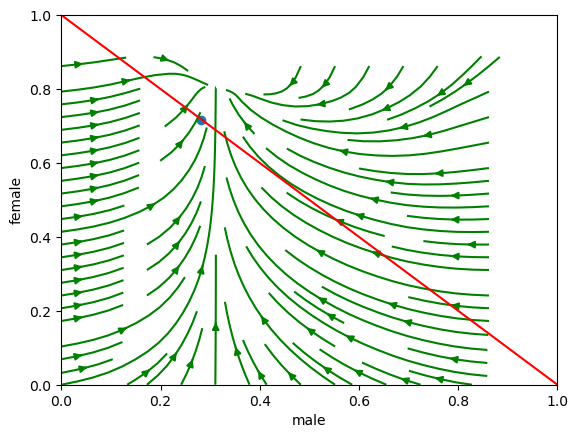

In [376]:

cpcx = 0
cmy = 0
cmx, cpcy = np.meshgrid(np.linspace(0,1,N),np.linspace(0,1,N))

cmxgraph = np.linspace(0,1,N)
u = (W(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx+h)-W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx))/W1(x,y,a,cpcx,cpcy,cpcx,cmx,cmy,cmx)
v = (W1(y,x,a,cpcy,cpcx,cpcy+h,cmy,cmx,cmy)-W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy))/W1(y,x,a,cpcy,cpcx,cpcy,cmy,cmx,cmy)

plt.streamplot(cmx, cpcy, u, v, color='g')
plt.xlabel('male')
plt.ylabel('female')
plt.plot(cmxgraph,1-cmxgraph,'red')
plt.scatter(0.282,0.717)